# Lab 2: Classification

**ECON5129 Statistical Machine Learning** &middot; Adam Smith Business School, University of Glasgow

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/korobilis/ECON5129-labs/blob/main/solutions/lab02_classification_solutions.ipynb)

This lab accompanies Lecture 2. By the end of the session you should be able to:

1. State a classification problem as a decision rule and evaluate it under 0-1 loss.
2. Implement $k$-nearest neighbours from scratch and choose $k$ by test error.
3. Compute the Bayes classifier and the Bayes error rate when the data generating process is known, and use it as the yardstick every other classifier is measured against.
4. Fit the plug-in classifiers, linear and quadratic discriminant analysis and naive Bayes, and say when each is appropriate.
5. Explain why regressing a binary label on predictors is a poor idea, and what goes wrong with three or more classes.
6. Estimate logistic regression by gradient ascent on the log-likelihood.
7. Evaluate a classifier properly: confusion matrix, precision, recall, ROC, AUC, and the threshold implied by asymmetric costs.

**Plan for the session**

| Time | Part |
|---|---|
| 0:00 - 0:10 | Setup and the classification problem |
| 0:10 - 0:35 | Part 2. Nearest neighbours |
| 0:35 - 1:00 | Part 3. The Bayes classifier and plug-in rules |
| 1:00 - 1:15 | Part 4. Least squares on labels |
| 1:15 - 1:35 | Part 5. Logistic regression |
| 1:35 - 2:00 | Part 6. Evaluation, on US recession data |

## Setup

**On Colab, save your own copy first**: `File` &rarr; `Save a copy in Drive`.

In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/korobilis/ECON5129-labs/main"

if not os.path.exists("econ5129_utils.py"):
    urllib.request.urlretrieve(f"{REPO_RAW}/econ5129_utils.py", "econ5129_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import econ5129_utils as e5

e5.set_style()
rng = np.random.default_rng(5129)

## Part 1. The classification problem

The response is now a label $y_i \in \{0, 1\}$ rather than a number. A classifier is a function $\widehat{G}: \mathbb{R}^p \to \{0, 1\}$, and under 0-1 loss its risk is simply the probability of a mistake,

$$ \mathbb{E}\left[ \mathbb{1}\{ \widehat{G}(\mathbf{x}) \neq y \} \right] . $$

We simulate two Gaussian classes in two dimensions, so that the decision boundary can be drawn and the truth is known.

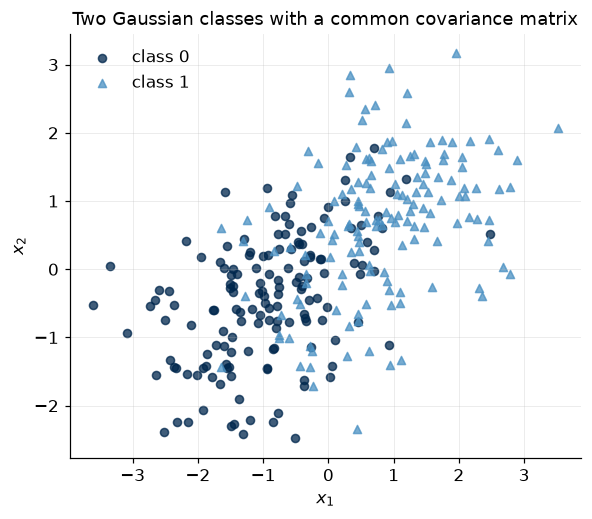

In [2]:
def simulate_classes(n_per_class, mu0, mu1, cov0, cov1, generator):
    """Draw a balanced two-class Gaussian sample."""
    X0 = generator.multivariate_normal(mu0, cov0, size=n_per_class)
    X1 = generator.multivariate_normal(mu1, cov1, size=n_per_class)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(int)
    order = generator.permutation(len(y))
    return X[order], y[order]


mu0, mu1 = np.array([-1.0, -0.5]), np.array([1.0, 0.8])
cov_common = np.array([[1.0, 0.4], [0.4, 1.0]])

X_train, y_train = simulate_classes(150, mu0, mu1, cov_common, cov_common, rng)
X_test, y_test = simulate_classes(1000, mu0, mu1, cov_common, cov_common, rng)

fig, ax = plt.subplots(figsize=(6, 5))
for label, marker in [(0, "o"), (1, "^")]:
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1], marker=marker, s=28,
               color=e5.COLORS[label], alpha=0.75, label=f"class {label}")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Two Gaussian classes with a common covariance matrix")
ax.legend()
plt.show()

We will draw a lot of decision boundaries, so it is worth writing the plotting code once.

In [3]:
def plot_boundary(predict, X, y, ax, title=""):
    """Shade the predicted class over a grid and overlay the sample."""
    pad = 0.5
    x1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 250)
    x2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 250)
    G1, G2 = np.meshgrid(x1, x2)
    grid = np.column_stack([G1.ravel(), G2.ravel()])

    Z = np.asarray(predict(grid)).reshape(G1.shape)
    ax.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5], colors=[e5.COLORS[0], e5.COLORS[1]], alpha=0.18)
    ax.contour(G1, G2, Z, levels=[0.5], colors="black", linewidths=1.0)

    for label, marker in [(0, "o"), (1, "^")]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], marker=marker, s=16,
                   color=e5.COLORS[label], alpha=0.8)
    ax.set_title(title)
    return ax

## Part 2. Nearest neighbours

The $k$-nearest neighbour rule assigns the majority label among the $k$ closest training points,

$$ \widehat{G}(\mathbf{x}) = \mathbb{1}\left\{ \frac{1}{k} \sum_{i \in N_k(\mathbf{x})} y_i > 0.5 \right\}, $$

where $N_k(\mathbf{x})$ collects the indices of the $k$ nearest training observations. There is no estimation step: the training data *is* the model.

In [4]:
def knn_predict(X_new, X_train, y_train, k):
    """Majority vote among the k nearest training points, Euclidean distance."""
    k = min(k, len(y_train))
    diff = X_new[:, None, :] - X_train[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=2))
    nearest = np.argpartition(dist, kth=k - 1, axis=1)[:, :k]
    return (y_train[nearest].mean(axis=1) > 0.5).astype(int)


for k in [1, 15, 101]:
    err = np.mean(knn_predict(X_test, X_train, y_train, k) != y_test)
    print(f"k = {k:>4}: test error rate = {err:.4f}")

k =    1: test error rate = 0.2320
k =   15: test error rate = 0.1565
k =  101: test error rate = 0.1470


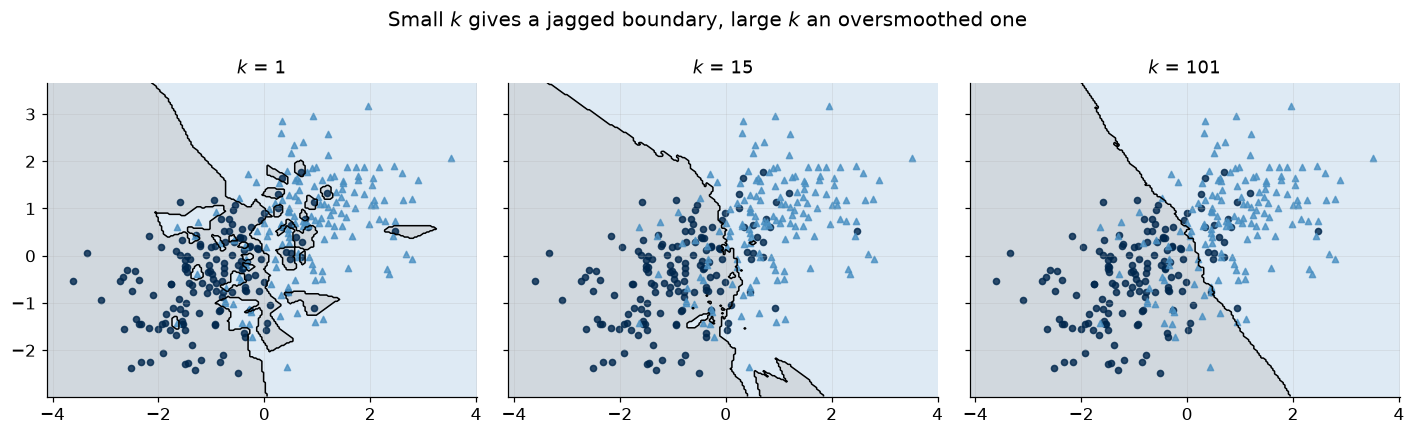

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, k in zip(axes, [1, 15, 101]):
    plot_boundary(lambda g, k=k: knn_predict(g, X_train, y_train, k),
                  X_train, y_train, ax, title=f"$k$ = {k}")
fig.suptitle("Small $k$ gives a jagged boundary, large $k$ an oversmoothed one")
fig.tight_layout()
plt.show()

The effective complexity of $k$-nearest neighbours is roughly $n/k$, so small $k$ means a flexible model. At $k = 1$ the training error is exactly zero and the boundary chases individual observations. This is the same overfitting seen with high degree polynomials in Lab 1, wearing different clothes.

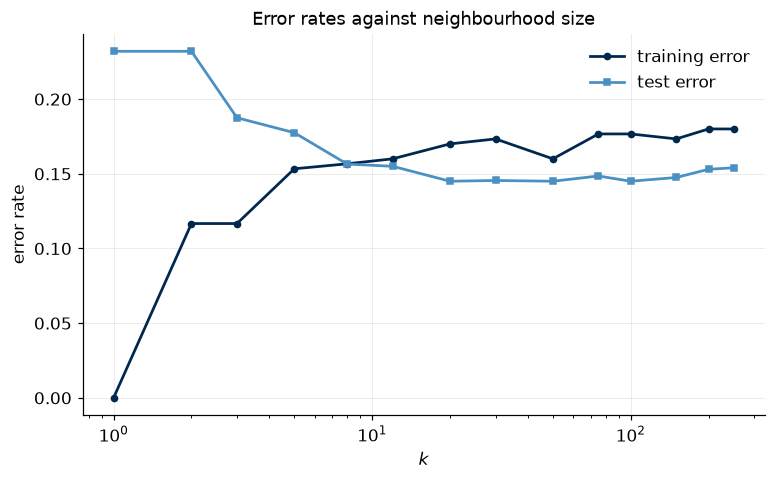

best k on the test set: 20


In [6]:
k_grid = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 250]
train_err, test_err = [], []

for k in k_grid:
    train_err.append(np.mean(knn_predict(X_train, X_train, y_train, k) != y_train))
    test_err.append(np.mean(knn_predict(X_test, X_train, y_train, k) != y_test))

fig, ax = plt.subplots()
ax.plot(k_grid, train_err, marker="o", ms=4, label="training error")
ax.plot(k_grid, test_err, marker="s", ms=4, label="test error")
ax.set_xscale("log")
ax.set_xlabel("$k$")
ax.set_ylabel("error rate")
ax.set_title("Error rates against neighbourhood size")
ax.legend()
plt.show()

print(f"best k on the test set: {k_grid[int(np.argmin(test_err))]}")

### Exercise 1

Choosing $k$ by test error is cheating: in practice the test set is not available. Use cross-validation instead.

1. Write a function `cv_error(k, X, y, n_folds=5)` that splits the training data into folds, predicts each fold using the remaining data, and returns the average error rate.
2. Evaluate it across the grid above and plot the cross-validated error.
3. Does the cross-validated choice of $k$ match the test-set choice?

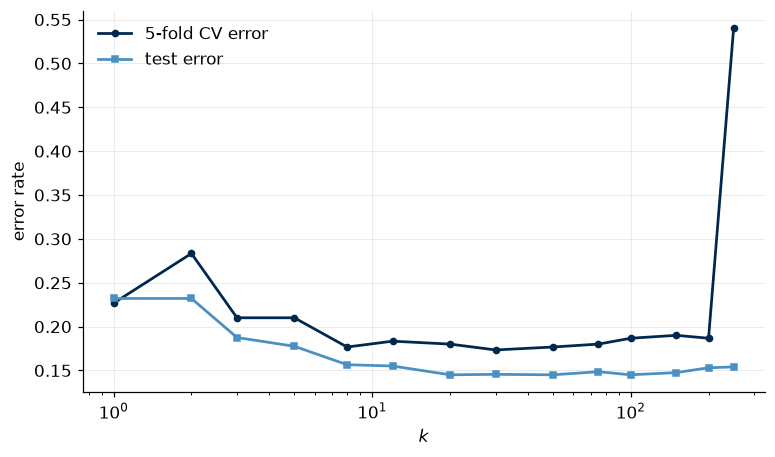

CV choice   : k = 30
test choice : k = 20


In [7]:
def cv_error(k, X, y, n_folds=5, generator=None):
    """Average error rate across n_folds cross-validation folds."""
    generator = generator or np.random.default_rng(0)
    folds = np.array_split(generator.permutation(len(y)), n_folds)
    errors = []
    for f in folds:
        mask = np.ones(len(y), dtype=bool)
        mask[f] = False
        pred = knn_predict(X[f], X[mask], y[mask], k)
        errors.append(np.mean(pred != y[f]))
    return float(np.mean(errors))


cv_err = [cv_error(k, X_train, y_train) for k in k_grid]

fig, ax = plt.subplots()
ax.plot(k_grid, cv_err, marker="o", ms=4, label="5-fold CV error")
ax.plot(k_grid, test_err, marker="s", ms=4, label="test error")
ax.set_xscale("log")
ax.set_xlabel("$k$")
ax.set_ylabel("error rate")
ax.legend()
plt.show()

print(f"CV choice   : k = {k_grid[int(np.argmin(cv_err))]}")
print(f"test choice : k = {k_grid[int(np.argmin(test_err))]}")

## Part 3. The Bayes classifier and plug-in rules

No classifier can do better than the rule that knows the truth. The Bayes classifier assigns

$$ G^{*}(\mathbf{x}) = \arg\max_{g} \; \Pr(y = g \mid \mathbf{x}), $$

and its error rate is the irreducible floor for this problem. Because we simulated the data we can compute it exactly, using the Gaussian densities and equal class priors.

In [8]:
def bayes_posterior(X_new, mu0, mu1, cov0, cov1, prior1=0.5):
    """Posterior probability of class 1 under known Gaussian class densities."""
    d0 = stats.multivariate_normal(mu0, cov0).pdf(X_new) * (1 - prior1)
    d1 = stats.multivariate_normal(mu1, cov1).pdf(X_new) * prior1
    return d1 / (d0 + d1)


def bayes_classifier(X_new, mu0, mu1, cov0, cov1, prior1=0.5):
    return (bayes_posterior(X_new, mu0, mu1, cov0, cov1, prior1) > 0.5).astype(int)


X_big, y_big = simulate_classes(50000, mu0, mu1, cov_common, cov_common, rng)
bayes_error = np.mean(bayes_classifier(X_big, mu0, mu1, cov_common, cov_common) != y_big)

print(f"Bayes error rate        : {bayes_error:.4f}")
print(f"best k-NN test error    : {min(test_err):.4f}")

Bayes error rate        : 0.1486
best k-NN test error    : 0.1450


With a common covariance matrix the Bayes boundary is exactly linear, which is the result the lecture derives algebraically. Estimating the two means and the shared covariance from data and plugging them in gives **linear discriminant analysis**. Allowing separate covariance matrices gives **quadratic discriminant analysis**, and assuming the predictors are conditionally independent gives **naive Bayes**.

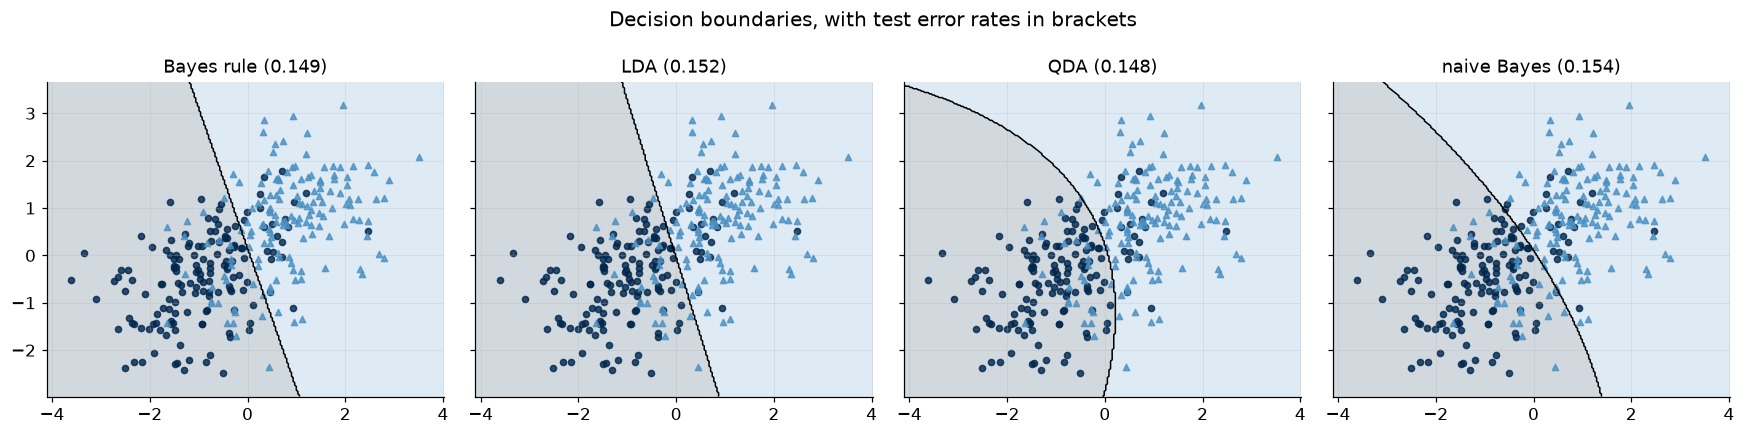

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "naive Bayes": GaussianNB(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
plot_boundary(lambda g: bayes_classifier(g, mu0, mu1, cov_common, cov_common),
              X_train, y_train, axes[0], title=f"Bayes rule ({bayes_error:.3f})")

for ax, (name, model) in zip(axes[1:], models.items()):
    model.fit(X_train, y_train)
    err = np.mean(model.predict(X_test) != y_test)
    plot_boundary(model.predict, X_train, y_train, ax, title=f"{name} ({err:.3f})")

fig.suptitle("Decision boundaries, with test error rates in brackets")
fig.tight_layout()
plt.show()

### Exercise 2

The three plug-in classifiers make different assumptions, so construct a problem where those assumptions matter.

1. Simulate a second dataset in which the two classes have *different* covariance matrices, for example $\Sigma_0 = \mathbf{I}$ and $\Sigma_1$ with variances 3 and 0.5 and correlation $-0.6$. Keep the means close together.
2. Fit LDA, QDA and naive Bayes, and compute the Bayes error for this new problem.
3. Plot the four boundaries. Which classifier is now closest to the Bayes rule, and why does LDA fail?

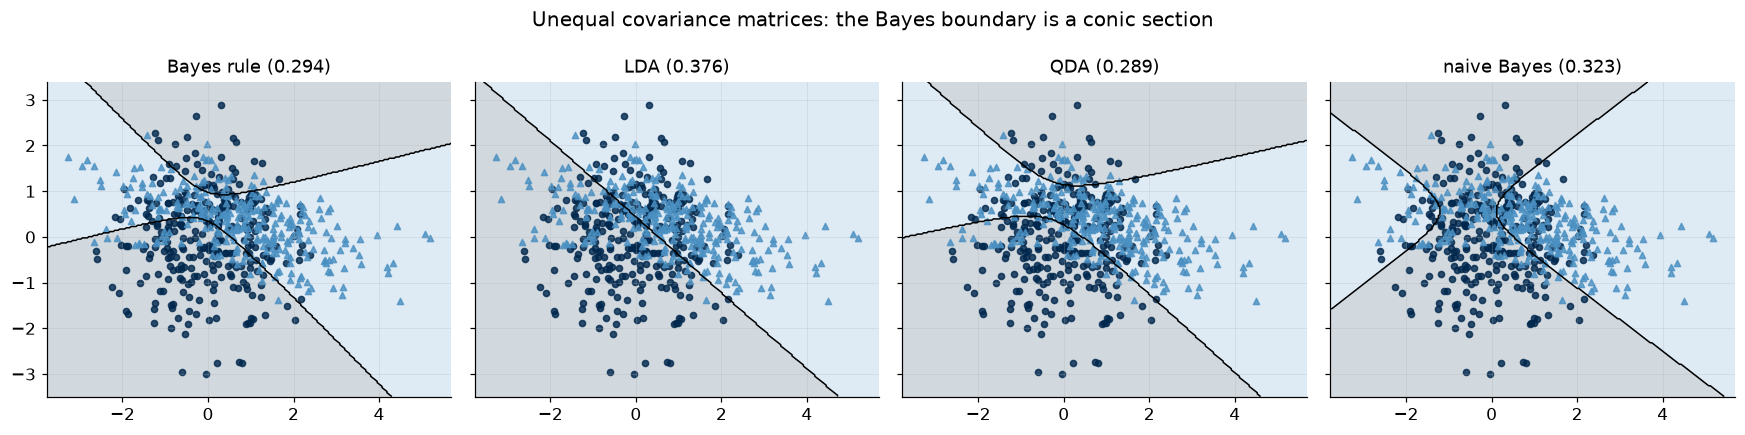

In [10]:
cov0_b = np.eye(2)
cov1_b = np.array([[3.0, -0.6 * np.sqrt(3 * 0.5)], [-0.6 * np.sqrt(3 * 0.5), 0.5]])
mu0_b, mu1_b = np.array([0.0, 0.0]), np.array([0.6, 0.3])

Xb_train, yb_train = simulate_classes(300, mu0_b, mu1_b, cov0_b, cov1_b, rng)
Xb_test, yb_test = simulate_classes(2000, mu0_b, mu1_b, cov0_b, cov1_b, rng)
Xb_big, yb_big = simulate_classes(30000, mu0_b, mu1_b, cov0_b, cov1_b, rng)

bayes_error_b = np.mean(bayes_classifier(Xb_big, mu0_b, mu1_b, cov0_b, cov1_b) != yb_big)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
plot_boundary(lambda g: bayes_classifier(g, mu0_b, mu1_b, cov0_b, cov1_b),
              Xb_train, yb_train, axes[0], title=f"Bayes rule ({bayes_error_b:.3f})")

for ax, (name, model) in zip(axes[1:], models.items()):
    model.fit(Xb_train, yb_train)
    err = np.mean(model.predict(Xb_test) != yb_test)
    plot_boundary(model.predict, Xb_train, yb_train, ax, title=f"{name} ({err:.3f})")

fig.suptitle("Unequal covariance matrices: the Bayes boundary is a conic section")
fig.tight_layout()
plt.show()

## Part 4. Least squares on labels

Nothing stops you regressing a 0/1 variable on predictors and thresholding the fit at one half. Two things go wrong. The fitted values are not probabilities, and with more than two classes some classes can be masked entirely.

In [11]:
X_design = np.column_stack([np.ones(len(y_train)), X_train])
beta_lin, *_ = np.linalg.lstsq(X_design, y_train.astype(float), rcond=None)
fitted = X_design @ beta_lin

print(f"fitted values range from {fitted.min():.3f} to {fitted.max():.3f}")
print(f"share outside [0, 1]: {np.mean((fitted < 0) | (fitted > 1)):.3f}")

fitted values range from -0.325 to 1.413
share outside [0, 1]: 0.157


The masking problem is easiest to see with three classes strung out along a line. The middle class is never the largest fitted value anywhere, so a linear regression on indicator variables never predicts it.

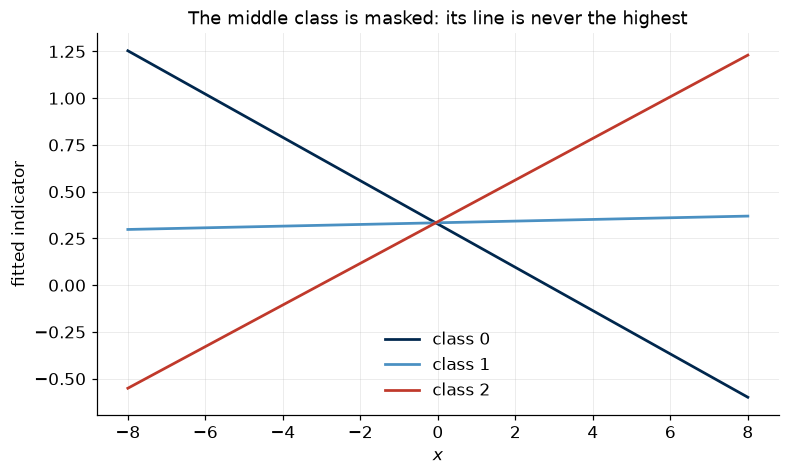

classes ever predicted across the grid: [0, 2]


In [12]:
centres = [-4.0, 0.0, 4.0]
x_masked = np.concatenate([c + rng.normal(scale=1.0, size=100) for c in centres])
g_masked = np.repeat([0, 1, 2], 100)

Z = np.column_stack([np.ones(len(x_masked)), x_masked])
Y_ind = np.zeros((len(x_masked), 3))
Y_ind[np.arange(len(x_masked)), g_masked] = 1.0
B, *_ = np.linalg.lstsq(Z, Y_ind, rcond=None)

grid_x = np.linspace(-8, 8, 400)
fits = np.column_stack([np.ones(400), grid_x]) @ B

fig, ax = plt.subplots()
for g in range(3):
    ax.plot(grid_x, fits[:, g], color=e5.COLORS[g], label=f"class {g}")
ax.set_xlabel("$x$")
ax.set_ylabel("fitted indicator")
ax.set_title("The middle class is masked: its line is never the highest")
ax.legend()
plt.show()

predicted = fits.argmax(axis=1)
print(f"classes ever predicted across the grid: {sorted(set(predicted.tolist()))}")

## Part 5. Logistic regression

Logistic regression models the posterior probability directly,

$$ \Pr(y_i = 1 \mid \mathbf{x}_i) = \frac{\exp(\mathbf{x}_i'\boldsymbol{\beta})}{1 + \exp(\mathbf{x}_i'\boldsymbol{\beta})}, $$

and estimates $\boldsymbol{\beta}$ by maximising the log-likelihood

$$ \ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \mathbf{x}_i'\boldsymbol{\beta} - \log\left(1 + e^{\mathbf{x}_i'\boldsymbol{\beta}}\right) \right] . $$

There is no closed form, so we climb the likelihood. The gradient has a memorable form: the design matrix multiplied by the vector of prediction errors,

$$ \nabla \ell(\boldsymbol{\beta}) = \mathbf{X}'(\mathbf{y} - \mathbf{p}). $$

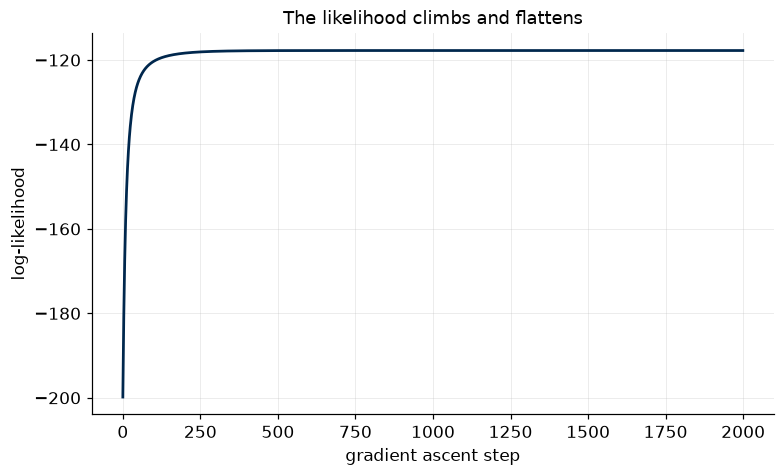

In [13]:
def sigmoid(z):
    """Numerically stable logistic function."""
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def logistic_gradient_ascent(X, y, learning_rate=0.1, n_steps=2000):
    """Maximise the logistic log-likelihood by gradient ascent."""
    beta = np.zeros(X.shape[1])
    path = []
    for _ in range(n_steps):
        p = sigmoid(X @ beta)
        beta = beta + learning_rate * X.T @ (y - p) / len(y)
        loglik = np.sum(y * (X @ beta) - np.logaddexp(0.0, X @ beta))
        path.append(loglik)
    return beta, np.array(path)


beta_logit, loglik_path = logistic_gradient_ascent(X_design, y_train.astype(float))

fig, ax = plt.subplots()
ax.plot(loglik_path)
ax.set_xlabel("gradient ascent step")
ax.set_ylabel("log-likelihood")
ax.set_title("The likelihood climbs and flattens")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

# A very large C switches the penalty off, matching the unpenalised likelihood above.

sk_logit = LogisticRegression(C=1e10, max_iter=5000).fit(X_train, y_train)
sk_coef = np.concatenate([sk_logit.intercept_, sk_logit.coef_.ravel()])

print(pd.DataFrame(
    {"gradient ascent": beta_logit, "scikit-learn": sk_coef},
    index=["intercept", "x1", "x2"],
).round(4))

           gradient ascent  scikit-learn
intercept           0.0562        0.0563
x1                  1.6659        1.6658
x2                  0.3297        0.3295


### Exercise 3

The learning rate governs whether gradient ascent converges quickly, slowly, or not at all. This is the same trade-off that dominates Lecture 7.

1. Run the ascent with learning rates 0.001, 0.05, 0.5 and 50, recording the log-likelihood path for each.
2. Plot the four paths on one figure.
3. Describe what goes wrong at each extreme, and check whether the final coefficients agree with `scikit-learn` in each case.

rate   0.001: max |coefficient difference| = 1.1117


rate    0.05: max |coefficient difference| = 0.0023


rate     0.5: max |coefficient difference| = 0.0002
rate    50.0: max |coefficient difference| = 33.9395


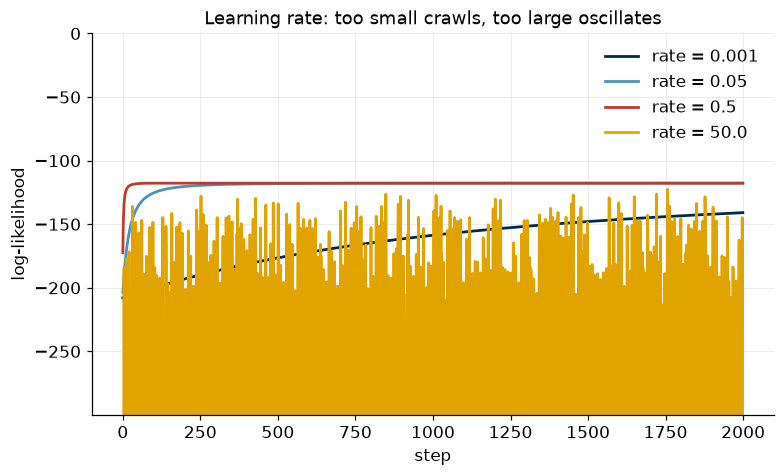

In [15]:
rates = [0.001, 0.05, 0.5, 50.0]

fig, ax = plt.subplots()
for lr in rates:
    b, path = logistic_gradient_ascent(X_design, y_train.astype(float), learning_rate=lr)
    ax.plot(path, label=f"rate = {lr}")
    print(f"rate {lr:>7}: max |coefficient difference| = "
          f"{np.max(np.abs(b - sk_coef)):.4f}")
ax.set_xlabel("step")
ax.set_ylabel("log-likelihood")
ax.set_ylim(np.min(loglik_path) * 1.5, 0)
ax.set_title("Learning rate: too small crawls, too large oscillates")
ax.legend()
plt.show()

## Part 6. Evaluation, on US recession data

Error rates alone are close to useless when classes are unbalanced, and recessions are rare: roughly one month in seven since 1960. A classifier that always predicts "no recession" is right about 86% of the time and completely worthless.

The task is to nowcast the NBER recession indicator from current macroeconomic conditions, using the FRED-MD panel.

In [16]:
data, codes = e5.load_fredmd()
transformed = e5.fredmd_transform(data, codes)

features = ["UNRATE", "CLAIMSx", "INDPRO", "PAYEMS", "T10YFFM", "S&P 500", "AWHMAN", "HOUST"]
panel = transformed[features].dropna().loc["1960-01":"2019-12"]

recession = e5.load_usrec().reindex(panel.index)
mask = recession.notna()
X_macro = panel[mask.to_numpy()].to_numpy()
y_macro = recession[mask].to_numpy().astype(int)

split = int(0.7 * len(y_macro))
X_tr, X_te = X_macro[:split], X_macro[split:]
y_tr, y_te = y_macro[:split], y_macro[split:]

print(f"training: {len(y_tr)} months, {y_tr.mean():.1%} in recession")
print(f"testing : {len(y_te)} months, {y_te.mean():.1%} in recession")

training: 503 months, 14.9% in recession
testing : 217 months, 8.3% in recession


The split is chronological, not random. Shuffling time series observations lets the classifier learn from the future to predict the past, which inflates every performance measure reported.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
clf.fit(X_tr, y_tr)

prob_te = clf.predict_proba(X_te)[:, 1]
pred_te = (prob_te > 0.5).astype(int)

cm = confusion_matrix(y_te, pred_te)
print(pd.DataFrame(cm,
                   index=["actual expansion", "actual recession"],
                   columns=["predicted expansion", "predicted recession"]))

tn, fp, fn, tp = cm.ravel()
print(f"\naccuracy  : {(tp + tn) / cm.sum():.3f}")
print(f"always-expansion accuracy: {1 - y_te.mean():.3f}")
print(f"precision : {tp / (tp + fp) if tp + fp else float('nan'):.3f}")
print(f"recall    : {tp / (tp + fn):.3f}")

                  predicted expansion  predicted recession
actual expansion                  196                    3
actual recession                    5                   13

accuracy  : 0.963
always-expansion accuracy: 0.917
precision : 0.812
recall    : 0.722


The headline accuracy looks impressive until you compare it with the do-nothing benchmark printed beneath it. Most of that number is bought by predicting the common class. Recall is what matters here: of the recession months in the evaluation sample, how many did we actually catch?

The ROC curve traces out every threshold at once.

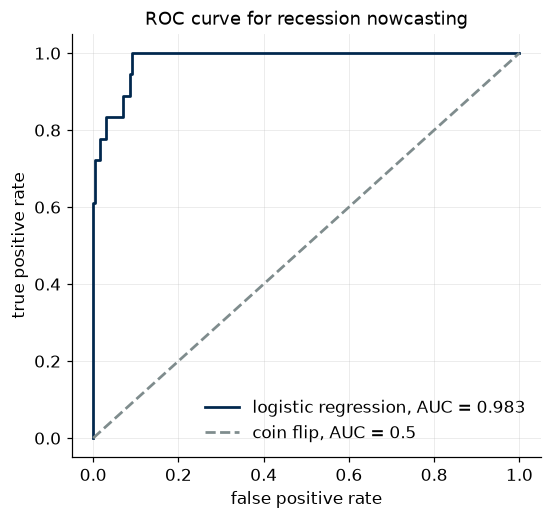

In [18]:
fpr, tpr, thresholds = roc_curve(y_te, prob_te)
auc = roc_auc_score(y_te, prob_te)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=e5.COLORS[0], label=f"logistic regression, AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], color=e5.COLORS[6], ls="--", label="coin flip, AUC = 0.5")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve for recession nowcasting")
ax.legend()
plt.show()

### Exercise 4

The 0.5 threshold is an arbitrary default. It is optimal only when a false alarm and a missed recession are equally costly, which they are not.

Suppose missing a recession costs $c_{FN} = 10$ and a false alarm costs $c_{FP} = 1$.

1. For each threshold on a grid from 0.01 to 0.99, compute the expected cost $c_{FN} \times \text{FN} + c_{FP} \times \text{FP}$ on the evaluation sample.
2. Plot cost against threshold and find the minimiser.
3. Report the confusion matrix at that threshold, and compare it with the one at 0.5. How many extra false alarms did you accept, and how many recession months did you gain?

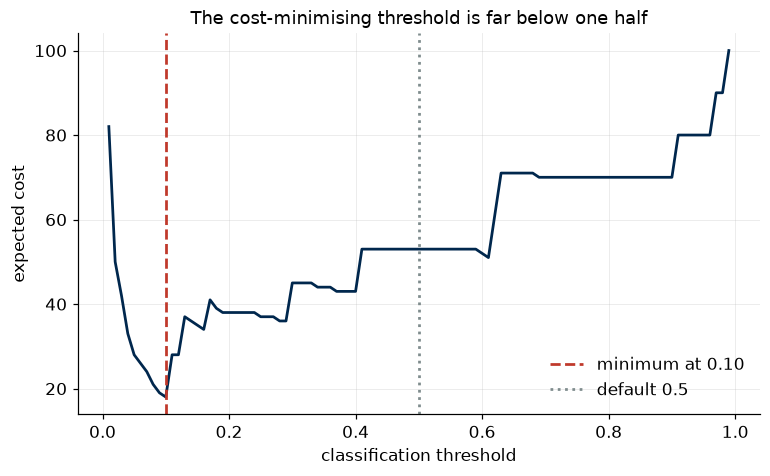

                  predicted expansion  predicted recession
actual expansion                  181                   18
actual recession                    0                   18


In [19]:
c_fn, c_fp = 10.0, 1.0
grid_t = np.linspace(0.01, 0.99, 99)

costs = []
for t in grid_t:
    pred = (prob_te > t).astype(int)
    fp_t = np.sum((pred == 1) & (y_te == 0))
    fn_t = np.sum((pred == 0) & (y_te == 1))
    costs.append(c_fn * fn_t + c_fp * fp_t)

best_t = grid_t[int(np.argmin(costs))]

fig, ax = plt.subplots()
ax.plot(grid_t, costs)
ax.axvline(best_t, color=e5.COLORS[2], ls="--", label=f"minimum at {best_t:.2f}")
ax.axvline(0.5, color=e5.COLORS[6], ls=":", label="default 0.5")
ax.set_xlabel("classification threshold")
ax.set_ylabel("expected cost")
ax.set_title("The cost-minimising threshold is far below one half")
ax.legend()
plt.show()

print(pd.DataFrame(confusion_matrix(y_te, (prob_te > best_t).astype(int)),
                   index=["actual expansion", "actual recession"],
                   columns=["predicted expansion", "predicted recession"]))

### Exercise 5

Compare classifiers properly on this problem.

1. Fit $k$-nearest neighbours (choose $k$ by cross-validation on the training sample), LDA, QDA, naive Bayes and logistic regression, each inside a pipeline that standardises the predictors.
2. Report accuracy, recall and AUC for each on the evaluation sample.
3. Plot all the ROC curves on one figure.

Which method would you actually use to call a recession, and does the ranking change if you rank by AUC rather than by accuracy?

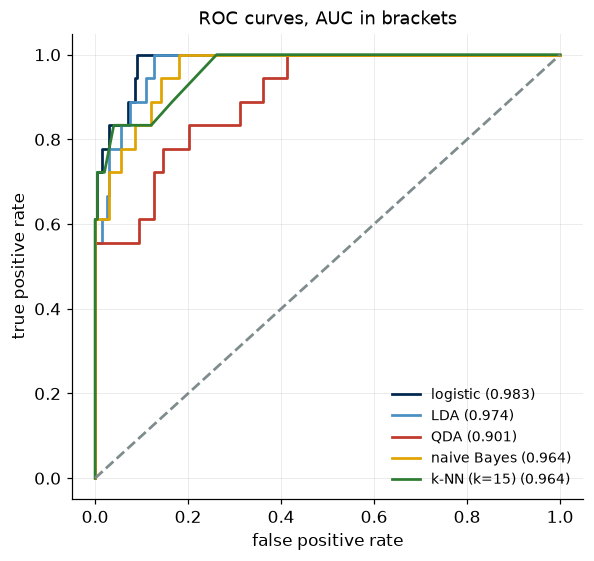

             accuracy  recall    AUC
classifier                          
logistic        0.963   0.722  0.983
LDA             0.945   0.667  0.974
QDA             0.949   0.556  0.901
naive Bayes     0.912   0.778  0.964
k-NN (k=15)     0.968   0.611  0.964


In [20]:
from sklearn.neighbors import KNeighborsClassifier

candidates = {
    "logistic": LogisticRegression(max_iter=5000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "naive Bayes": GaussianNB(),
    "k-NN (k=15)": KNeighborsClassifier(n_neighbors=15),
}

rows = []
fig, ax = plt.subplots(figsize=(6, 5.5))

for name, model in candidates.items():
    pipe = make_pipeline(StandardScaler(), model).fit(X_tr, y_tr)
    prob = pipe.predict_proba(X_te)[:, 1]
    pred = (prob > 0.5).astype(int)
    tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_te, pred).ravel()

    rows.append({
        "classifier": name,
        "accuracy": (tp_i + tn_i) / len(y_te),
        "recall": tp_i / (tp_i + fn_i),
        "AUC": roc_auc_score(y_te, prob),
    })

    f, t, _ = roc_curve(y_te, prob)
    ax.plot(f, t, label=f"{name} ({roc_auc_score(y_te, prob):.3f})")

ax.plot([0, 1], [0, 1], color=e5.COLORS[6], ls="--")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves, AUC in brackets")
ax.legend(fontsize=9)
plt.show()

print(pd.DataFrame(rows).set_index("classifier").round(3))

## Take-home challenges

1. **Nowcasting versus forecasting.** Repeat Part 6 predicting the recession indicator three months ahead rather than contemporaneously. How much of the performance was coming from information that would not have been available in real time?

2. **The curse of dimensionality for $k$-NN.** Simulate two Gaussian classes in $d$ dimensions where only the first two dimensions carry signal, for $d = 2, 5, 10, 25, 50$. Plot $k$-NN test error against $d$ alongside the LDA test error. Which degrades faster, and why?

3. **Probability calibration.** Split the evaluation sample by predicted probability into ten buckets and plot the realised recession frequency against the average predicted probability in each bucket. A well-calibrated classifier lies on the 45 degree line. Is logistic regression better calibrated than QDA here?

4. **Class weights.** `LogisticRegression` accepts `class_weight="balanced"`, which reweights the likelihood by inverse class frequency. Show that this is an alternative route to the same place as the cost-based threshold of Exercise 4, and work out the implied ratio of costs.

---

**Next**: Lecture 3 asks what to do when the number of predictors is large relative to the sample. Lab 3 builds ridge, LASSO and the elastic net from scratch and puts them to work on 363 macroeconomic predictors.